# Lecture 5 - Metropolis algorithm and hydrogen atom 

## Introduction and theory

### Metropolis algorithm M(RT)$^2$
The Metropolis algorithm is an advanced sampling technique first described in the pivotal paper "Equation of State Calculations by Fast Computing Machines" by Metropolis, Rosenbluth, Rosenbluth, Teller, and Teller (June 1953, The Journal of Chemical Physics).
The M(RT)$^2$ algorithm makes use of Markov chains to sample target probability distributions and it is related to rejection techniques since it involves explicitly proposing a guess value which can be rejected. 
The advantange of this method is the capability of sampling any probability distribution, in any dimension and without the need of knowing the normalization constant.
The main disadvantage is that the sampling can be correct only asymptotically and the successive variables may be highly correlated.

The algorithm operates by generating a sequence of states in a random walk $x_1, \dots, x_N$ with the goal of sampling from a specific target distribution $p(x)$. The core objective is to ensure that the marginal distribution of the walk, $d_N(x)$, converges asymptotically to the target, satisfying 
$$
\lim_{N \to \infty} d_N(x) = p(x)\ .
$$ 
This is achieved by modeling the walk as a stationary Markov process defined by a transition kernel $K(x|y)$, which represents the probability of moving to state $x$ given the current state $y$. For the distribution $p(x)$ to remain invariant under this process, the kernel must satisfy the integral equation 
$$
p(x) = \int K(x|y)p(y)dy\ .
$$
To simplify the construction of such a kernel, we rely on the principle of detailed balance, expressed as
$$
K(x|y)p(y) = K(y|x)p(x)
$$
This condition ensures that the probability of transitioning from $y$ to $x$ is perfectly balanced by the reverse transition, making $p(x)$ the stationary distribution. In practice, the transition kernel is decomposed into two distinct components: a proposal distribution $T(x|y)$, which suggests a candidate next state, and an acceptance probability $A(x|y)$, which decides whether to move to that candidate or stay at the current position. By defining the kernel as $K(x|y) = T(x|y) \times A(x|y)$ and setting the acceptance probability to
$$
A(x|y) = \min\left[1, \frac{T(y|x)p(x)}{T(x|y)p(y)}\right]$$
the detailed balance condition is maintained. In many applications, we use a symmetric proposal distribution where $T(x|y) = T(y|x)$, which simplifies the acceptance probability significantly to
$$
A(x|y) = \min\left[1, \frac{p(x)}{p(y)}\right]
$$
Through this mechanism, the random walk is biased toward regions of higher probability while still allowing for the exploration of the entire state space, eventually resulting in a set of samples that accurately represent $p(x)$.

The efficiency of this algorithm strongly depends on the step size of the random walk. If the step size is too small, the walk moves slowly, resulting in high autocorrelation where each sample is nearly identical to the previous one; while the acceptance rate will be high, the algorithm will take a very long time to explore the entire range of $p(x)$. If the step size is too large, the proposal is likely to jump in a region where $p(x)$ is nearly zero, leading to a very low acceptance ratio $A(x|y)$ and causing the stuck at the current position for many steps. 

### Our problem
In quantum physics a wave function, $\Psi$, is a mathematical description of the state of a quantum system. The wave function is a complex-valued probability amplitude, and the probabilities for the possible results of measurements made on the system can be derived from it.

For now on, let's consider the simple case of a non-relativistic single particle, without spin, in three spatial dimensions. The state of such a particle is completely described by its wave function, $\Psi(\vec{r},t)$, where $\vec{r}$ is position and $t$ is time.

For one spinless particle, if the wave function is interpreted as a probability amplitude, the square modulus of the wave function, $|\Psi(\vec{r},t)|^2$, is interpreted as the probability density that the particle is at $\vec{r}$ at time $t$. Once we have a probability density, we can use Monte Carlo.

#### Hydrogen atom
The wave functions of the eigenstates of an electron in a Hydrogen atom (this is the only atom for which the Schroedinger equation has been solved exactly) are expressed in terms of spherical harmonics and generalized Laguerre polynomials. It is convenient to use spherical coordinates, and the wave function can be separated into functions of each coordinate:

$$
\Psi_{n,l,m}(r,\theta,\phi)=
\sqrt{\left(\frac{2}{na_0}\right)^3 \frac{(n-l-1)!}{2n[(n+l)!]}}
e^{-r/na_0}\left(\frac{2r}{na_0}\right)^l L_{n-l-1}^{2l+1}\left(\frac{2r}{na_0}\right)
Y_l^m(\theta,\phi)
$$

where $a_0=4\pi\epsilon_0\hbar^2/m_e e^2=0.0529$ nm is the Bohr radius, $L_{n-l-1}^{2l+1}$ are the generalized Laguerre polynomials of degree $n-l-1$, $n=1,2,...$ is the principal quantum number, $l=0,1, ..., n-1$ the azimuthal quantum number, $m=-l, -l+1, ..., l-1, l$ the magnetic quantum number.

For example, the ground state wave function is:
$$
\Psi_{1,0,0}(r,\theta,\phi)=
\frac{a_0^{-3/2}}{\sqrt{\pi}} e^{-r/a_0} 
$$
whereas one of the three $2p$ excited state is:
$$
\Psi_{2,1,0}(r,\theta,\phi)=
\frac{a_0^{-5/2}}{8}\sqrt{\frac{2}{\pi}} r e^{-r/2a_0} \cos(\theta)
$$
Expectation values for the radius turns out to be exactly:
$$
\left\langle r \right\rangle_{\Psi_{1,0,0}} = \frac{3}{2}a_0
\quad
\left\langle r \right\rangle_{\Psi_{2,1,0}} = 5 a_0
$$


### Exercise 05.1
Use the Metropolis algorithm to sample $|\Psi_{1,0,0}(x,y,z)|^2$ and $|\Psi_{2,1,0}(x,y,z)|^2$ in Cartesian coordinates using, initially, an uniform transition probability $T(\vec{x}|\vec{y})$. Use the sampled positions to estimate $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$. As usual, use data blocking and give an estimate of the statistical uncertainties.

Show a picture of your estimations of $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$ and their uncertainties with a large number of *throws* $M$ (e.g. $M\ge 10^6$) as a function of the number of blocks, $N$.

- Use Bohr radius units, $a_0$ for distances
- Choose the step of the uniform transition probability $T(\vec{x}|\vec{y})$ in order to obtain 50% of acceptance in both cases
- Choose a reasonable starting point in the 3D space and equilibrate your sampling before to start measuring the radius. What do you observe when you start very far from the origin?
- How large should be the number of Monte Carlo Metropolis steps in each block?
- If you use a multivariate normal transition probability $T(\vec{x}|\vec{y})$, i.e. a Gaussian for each coordinate, your results for $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$ are equivalent?

### Implementation - Exercise 5.1
In this code a Markov Chain Monte Carlo technique is deployed to sample the hydrogen atom $1S$ and $2P$ orbitals. 

We designed this code in such a way that it asks to the user according to which distribution does he want to update the walkers' position
1. Uniform $\rightarrow$ random steps inside a cube of side $2 \times \text{step}$: using `rnd.Rannyu(-step[0], step[0])` ensuring that the detailed balance is satisfied.
2. Gaussian $\rightarrow$ random steps picked from a normal distribution with a standard deviation equal to `step` (also this distribution satisfies the detailed balance since it is symmetric around $0$).

Then we can decide the starting positions of the walkers for both $1S$ and $2P$ orbitals, in our case we started from two very different positions: one close to the region where we expect to have higher probability and one far away from it.

This choice of starting far away has been made in order to understand how well the code was working (down here are shown different plots that can prove the correct behavior).

Here are reported the step values decided for our configurations
| Quantity | $\delta_{\text{1S, uniform}}$ | $\delta_{\text{1S, gauss}}$ | $\delta_{\text{2P, uniform}}$ | $\delta_{\text{2P, gauss}}$ |
| :--- | :---: | :---: | :---: | :---: |
| **Value** | 1.22 | 0.7 | 2.8 | 1.6 |
The values have been chosen in order to achieve an acceptance rate of around $50%$.
#### How the algorithm works in our case?

Here is the workflow
1. We start from a point in the Cartesian space
2. We make a random trial move (uniform or gaussian) $\rightarrow$ random walk
3. We compute the minimum between $1$ and the ratio between the wavefunctions of the old and the new configuration $\rightarrow$ we obtain an acceptance ratio $\alpha$. 
4. We pick a random number $r$ in the range $[0,1)$ and
    - if $r \leq \alpha$ we accept the new position
    - if $r > \alpha$ we reject the new position, and the algorithm stays in the previous position.
5. We repeat this process iteratively.


In this way if the new random position is in a higher probability region, rather than the previous position, the ratio will be $ > 1$ and so the minimum will be $1$, thus leading to the certain acceptance of the move because the $r < \alpha$ for sure.

#### Parameters' choice and results' summary
The simulations were performed for $M=10^6$ steps divided into $N=100$ blocks, the averages and the errors were calculated using the data blocking technique after a thermalization process of $10^4$ steps.

The obtained values are reported into the table below, which shows similar results and errors for both uniform and gaussian distributions.
| Quantity | $r_{0,\text{1S}}$ |$\sigma_{r_{0,\text{1S}}}$| $r_{0,\text{2P}}$ |$\sigma_{r_{0,\text{2P}}}$ |
| :--- | :---: | :---: | :---: | :---: |
| Uniform (close start) | 1.498 | 0.004 | 5.000 | 0.004 |
| Uniform (far start) | 1.503 | 0.004 | 5.014 | 0.004 |
| Gaussian (close start) | 1.499 | 0.005 | 4.990 | 0.010 |
| Gaussian (far start) | 1.506 | 0.006 | 5.002 | 0.012 |

Below are reported the pictures of the convergence processes and also the 3D scatter plots of the sampled positions.

The combination of these kind of plots shows how the Metropolis algorithm can fastly reach the high-probability regions also when the initial position is far away.

In [39]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.gridspec as gridspec
plt.style.use('default')
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

### RW step drawn from a uniform distribution 

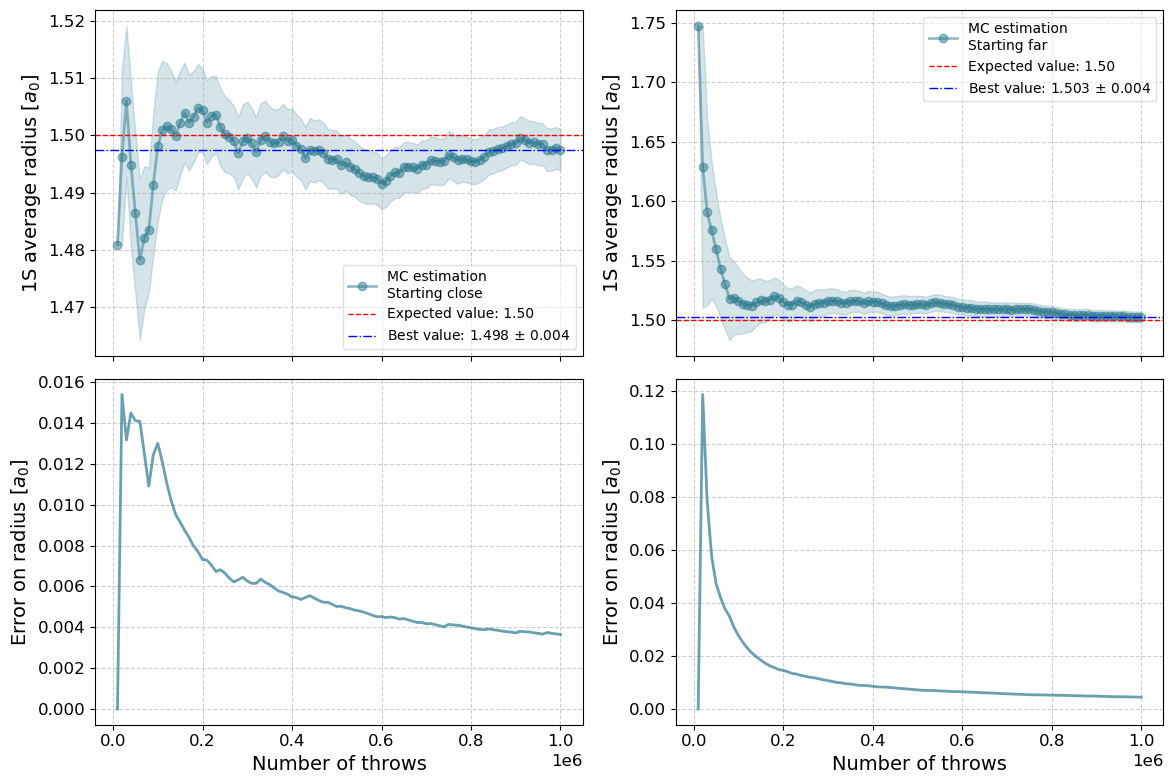

In [40]:
file_1s = "output_average_1s_uniform.data"
file_1s_far = "output_average_1s_far_uniform.data"
x_1s, y_1s, error_1s = np.loadtxt(file_1s, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x_1s_far, y_1s_far, error_1s_far = np.loadtxt(file_1s_far, usecols=(0, 1, 2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.patch.set_facecolor('white')  

viridis = plt.cm.viridis
color_1s = viridis(0.4)
ref_color = 'red'
ref_color_2 = 'blue'

expected_val = 1.5
best_val_near = y_1s[99]
best_val_far = y_1s_far[99]

# Plot 1S - Near
ax[0, 0].plot(x_1s, y_1s, marker='o', color=color_1s, alpha=0.5, label='MC estimation \nStarting close')
ax[0, 0].fill_between(x_1s, y_1s+error_1s,y_1s-error_1s, color=color_1s, alpha=0.2)
ax[0, 0].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 0].axhline(
    y=best_val_near,
    color=ref_color_2,
    linestyle='-.',
    linewidth=1,
    label=rf'Best value: {best_val_near:.3f} $\pm$ {error_1s[99]:.3f}'
)
ax[0, 0].set_ylabel('1S average radius [$a_0$]')
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].tick_params(axis='x', labelbottom=False)
ax[0, 0].legend(loc='lower right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Plot 1S - Far
ax[0, 1].plot(x_1s_far, y_1s_far, marker='o', color=color_1s, alpha=0.5, label='MC estimation \nStarting far')
ax[0, 1].fill_between(x_1s_far, y_1s_far+error_1s_far,y_1s_far-error_1s_far, color=color_1s, alpha=0.2)
ax[0, 1].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 1].axhline(y=best_val_far, color=ref_color_2, linestyle='-.', linewidth=1,
                     label=rf'Best value: {best_val_far:.3f} $\pm$ {error_1s_far[99]:.3f}'
)
ax[0, 1].set_ylabel('1S average radius [$a_0$]')
ax[0, 1].grid(True, linestyle='--', alpha=0.6)
ax[0, 1].tick_params(axis='x', labelbottom=False)
ax[0, 1].legend(loc='upper right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Errori
ax[1, 0].plot(x_1s, error_1s, '-', color=color_1s, alpha=0.7)
ax[1, 0].set_xlabel('Number of throws')
ax[1, 0].set_ylabel('Error on radius [$a_0$]')
ax[1, 0].grid(True, linestyle='--', alpha=0.6)

ax[1, 1].plot(x_1s_far, error_1s_far, '-', color=color_1s, alpha=0.7)
ax[1, 1].set_xlabel('Number of throws')
ax[1, 1].set_ylabel('Error on radius [$a_0$]')
ax[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


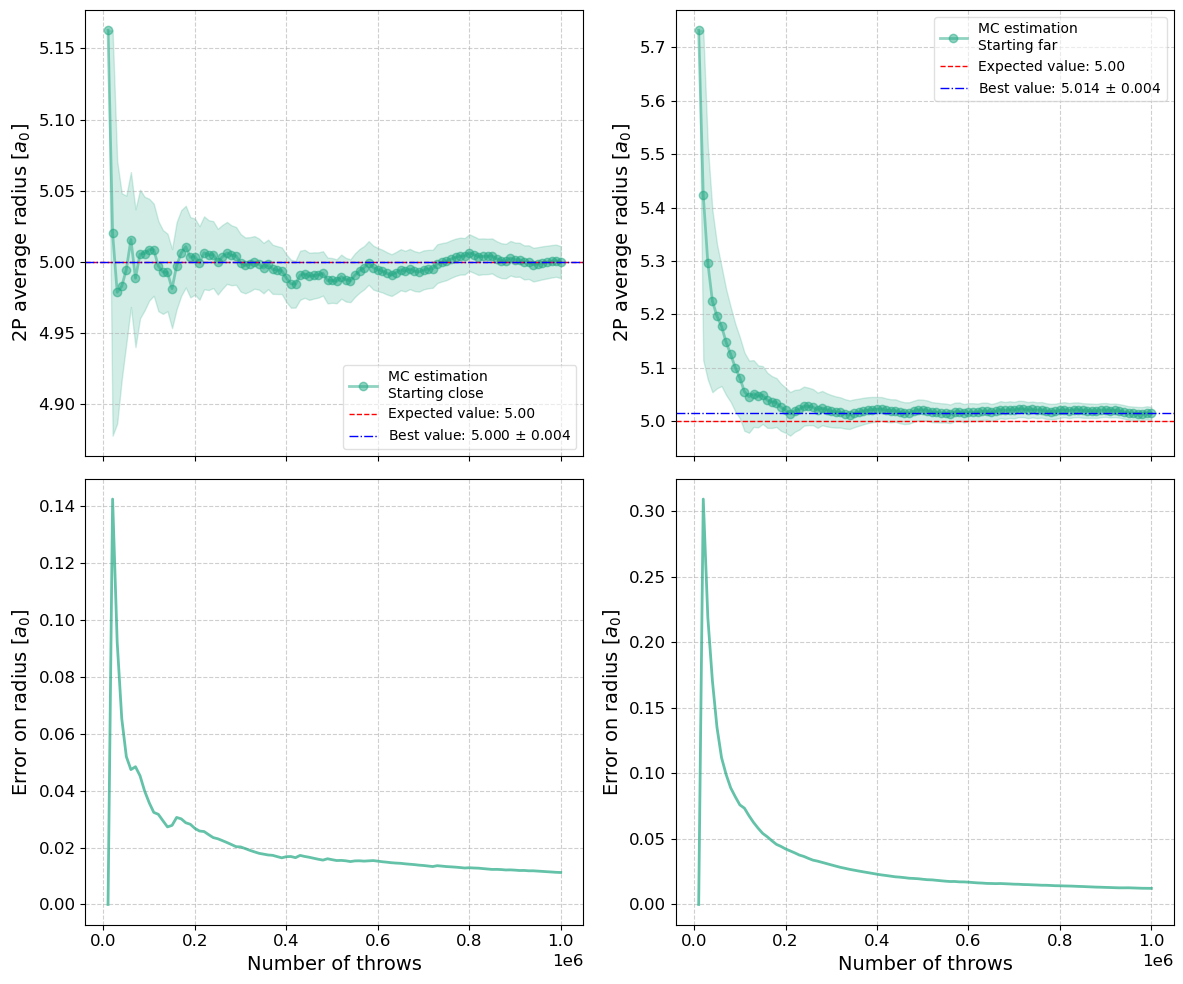

In [41]:
file_2p = "output_average_2p_uniform.data"
file_2p_far = "output_average_2p_far_uniform.data"
x_2p, y_2p, error_2p = np.loadtxt(file_2p, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x_2p_far, y_2p_far, error_2p_far = np.loadtxt(file_2p_far, usecols=(0, 1, 2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor('white')  

viridis = plt.cm.viridis
color_2p = viridis(0.6)
ref_color = 'red'
ref_color_2 = 'blue'

expected_val = 5.
best_val_near = y_2p[99]
best_val_far = y_2p_far[99]

# Plot 2P - Near

ax[0, 0].plot(x_2p, y_2p, marker='o', color=color_2p, alpha=0.5, label='MC estimation \nStarting close')
ax[0, 0].fill_between(x_2p, y_2p+error_2p,y_2p-error_2p, color=color_2p, alpha=0.2)
ax[0, 0].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 0].axhline(
    y=best_val_near,
    color=ref_color_2,
    linestyle='-.',
    linewidth=1,
    label=rf'Best value: {best_val_near:.3f} $\pm$ {error_1s[99]:.3f}')
ax[0, 0].set_ylabel('2P average radius [$a_0$]')
ax[0, 0].tick_params(axis='x', labelbottom=False)
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].legend(loc='lower right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Plot 2P - Far
ax[0, 1].plot(x_2p_far, y_2p_far, marker='o', color=color_2p, alpha=0.5, label='MC estimation \nStarting far')
ax[0, 1].fill_between(x_2p_far, y_2p_far+error_2p_far,y_2p_far-error_2p_far, color=color_2p, alpha=0.2)
ax[0, 1].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 1].axhline(y=best_val_far, color=ref_color_2, linestyle='-.', linewidth=1,
                     label=rf'Best value: {best_val_far:.3f} $\pm$ {error_1s_far[99]:.3f}')
ax[0, 1].set_ylabel('2P average radius [$a_0$]')
ax[0, 1].tick_params(axis='x', labelbottom=False)
ax[0, 1].grid(True, linestyle='--', alpha=0.6)
ax[0, 1].legend(loc='upper right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Errori
ax[1, 0].plot(x_2p, error_2p, '-', color=color_2p, alpha=0.7)
ax[1, 0].set_xlabel('Number of throws')
ax[1, 0].set_ylabel('Error on radius [$a_0$]')
ax[1, 0].grid(True, linestyle='--', alpha=0.6)

ax[1, 1].plot(x_2p_far, error_2p_far, '-', color=color_2p, alpha=0.7)
ax[1, 1].set_xlabel('Number of throws')
ax[1, 1].set_ylabel('Error on radius [$a_0$]')
ax[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


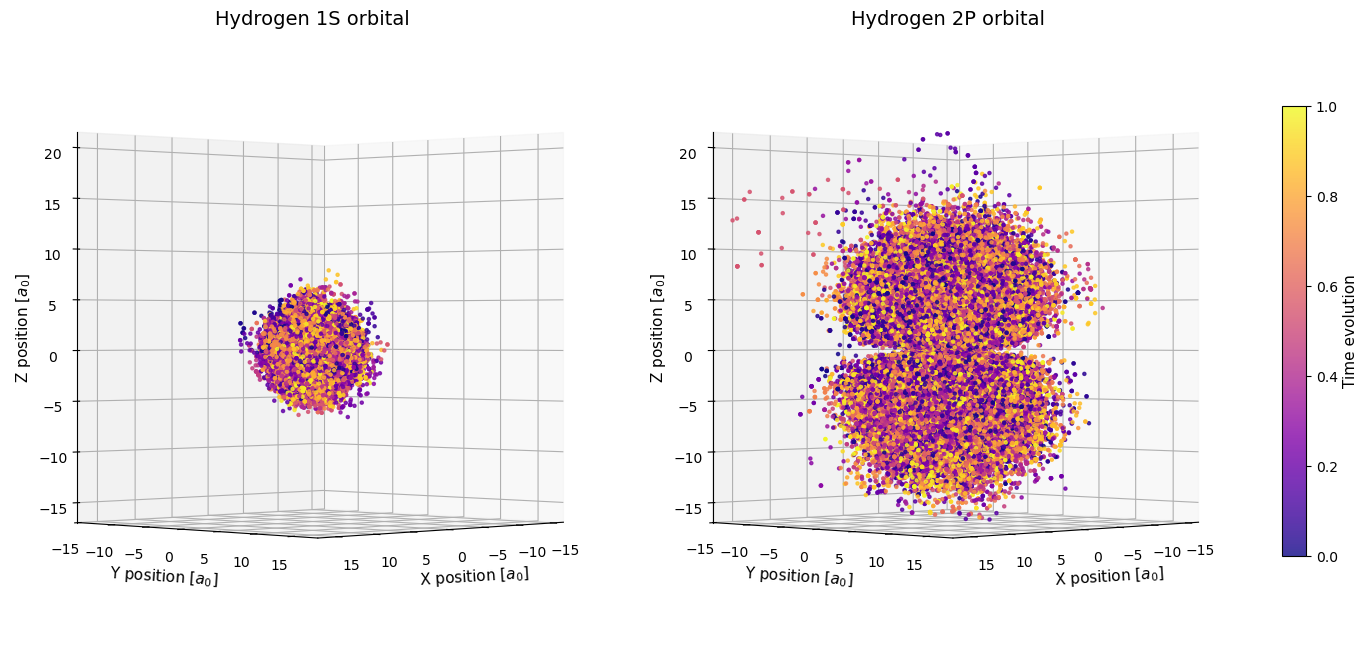

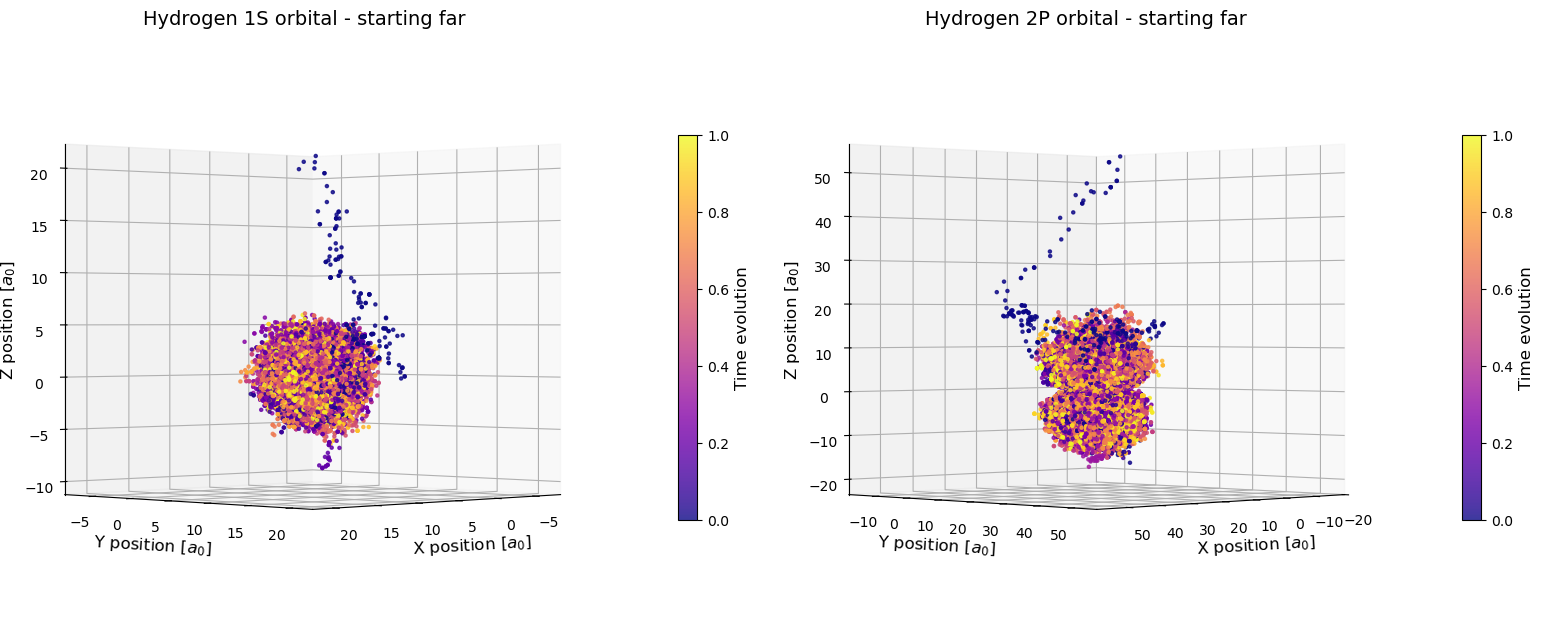

In [ ]:
data_1s = np.loadtxt("positions_1s_uniform.data")
data_2p = np.loadtxt("positions_2p_uniform.data")

all_data = np.vstack((data_1s, data_2p))
x_min, x_max = all_data[:, 0].min(), all_data[:, 0].max()
y_min, y_max = all_data[:, 1].min(), all_data[:, 1].max()
z_min, z_max = all_data[:, 2].min(), all_data[:, 2].max()

def set_equal_limits_and_aspect(ax):
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_box_aspect([x_max - x_min, y_max - y_min, z_max - z_min])

plt.style.use('default')
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

cmap = "plasma"
colors_1s = np.linspace(0, 1, len(data_1s))
colors_2p = np.linspace(0, 1, len(data_2p))

ax1 = fig.add_subplot(gs[0], projection='3d')
sc1 = ax1.scatter(data_1s[:, 0], data_1s[:, 1], data_1s[:, 2],
                  c=colors_1s, cmap=cmap, s=5, alpha=0.8)
ax1.set_title("Hydrogen 1S orbital", fontsize=14, color='black')
ax1.set_xlabel("X position [$a_0$]", fontsize=11)
ax1.set_ylabel("Y position [$a_0$]", fontsize=11)
ax1.set_zlabel("Z position [$a_0$]", fontsize=11)
ax1.view_init(elev=0, azim=45)
set_equal_limits_and_aspect(ax1)

ax2 = fig.add_subplot(gs[1], projection='3d')
sc2 = ax2.scatter(data_2p[:, 0], data_2p[:, 1], data_2p[:, 2],
                  c=colors_2p, cmap=cmap, s=5, alpha=0.8)
ax2.set_title("Hydrogen 2P orbital", fontsize=14, color='black')
ax2.set_xlabel("X position [$a_0$]", fontsize=11)
ax2.set_ylabel("Y position [$a_0$]", fontsize=11)
ax2.set_zlabel("Z position [$a_0$]", fontsize=11)
ax2.view_init(elev=0, azim=45)
set_equal_limits_and_aspect(ax2)

cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cbar = fig.colorbar(sc2, cax=cbar_ax)
cbar.set_label("Time evolution", fontsize=11)

plt.subplots_adjust(wspace=0.05, right=0.9)
plt.show()

# Starting far
#==============================================================================
data_1s_far = np.loadtxt("positions_1s_far_uniform.data")
data_2p_far = np.loadtxt("positions_2p_far_uniform.data")

fig2 = plt.figure(figsize=(16, 8))
ax3 = fig2.add_subplot(121, projection='3d')
colors_1s_far = np.linspace(0, 1, len(data_1s_far))
sc3 = ax3.scatter(data_1s_far[:, 0], data_1s_far[:, 1], data_1s_far[:, 2], 
                  c=colors_1s_far, cmap="plasma", s=5, alpha=0.8)

ax3.set_box_aspect((1, 1, 1)) 
cbar3 = fig2.colorbar(sc3, ax=ax3, shrink=0.5, pad=0.1)
cbar3.set_label("Time evolution", fontsize=12)

ax3.set_xlabel("X position [$a_0$]", fontsize=12)
ax3.set_ylabel("Y position [$a_0$]", fontsize=12)
ax3.set_zlabel("Z position [$a_0$]", fontsize=12)
ax3.set_title("Hydrogen 1S orbital - starting far", fontsize=14)
ax3.view_init(elev=0, azim=45)

ax4 = fig2.add_subplot(122, projection='3d')
colors_2p_far = np.linspace(0, 1, len(data_2p_far))
sc4 = ax4.scatter(data_2p_far[:, 0], data_2p_far[:, 1], data_2p_far[:, 2], 
                  c=colors_2p_far, cmap="plasma", s=5, alpha=0.8)

ax4.set_box_aspect((1, 1, 1))
cbar4 = fig2.colorbar(sc4, ax=ax4, shrink=0.5, pad=0.1)
cbar4.set_label("Time evolution", fontsize=12)

ax4.set_xlabel("X position [$a_0$]", fontsize=12)
ax4.set_ylabel("Y position [$a_0$]", fontsize=12)
ax4.set_zlabel("Z position [$a_0$]", fontsize=12)
ax4.set_title("Hydrogen 2P orbital - starting far ", fontsize=14)
ax4.view_init(elev=0, azim=45)

plt.tight_layout()
plt.show()


### RW step drawn from a gaussian distribution 

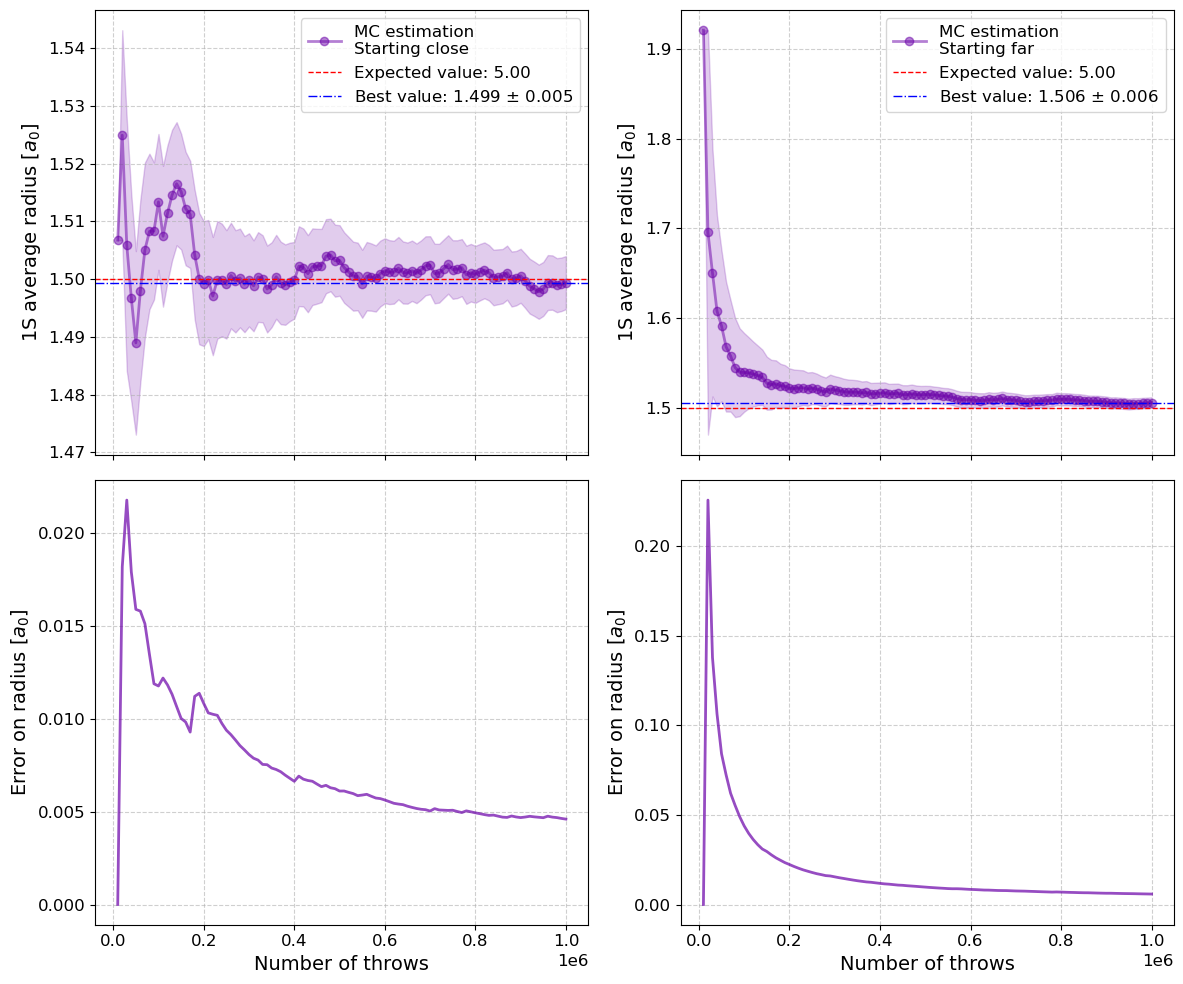

In [51]:
file_1s = "output_average_1s_gauss.data"
file_1s_far = "output_average_1s_far_gauss.data"
x_1s, y_1s, error_1s = np.loadtxt(file_1s, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x_1s_far, y_1s_far, error_1s_far = np.loadtxt(file_1s_far, usecols=(0, 1, 2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

plasma = plt.cm.plasma
color_1s = plasma(0.2)
ref_color = 'red'
ref_color_2 = 'blue'

# 1S - Near
ax[0, 0].plot(x_1s, y_1s, marker='o', color=color_1s, alpha=0.5, label='MC estimation \nStarting close')
ax[0, 0].fill_between(x_1s, y_1s+error_1s,y_1s-error_1s, color=color_1s, alpha=0.2)
ax[0, 0].axhline(y=1.5, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 0].axhline(y=y_1s[99], color=ref_color_2, linestyle='-.', linewidth=1,
                     label=rf'Best value: {y_1s[99]:.3f} $\pm$ {error_1s[99]:.3f}')
ax[0, 0].tick_params(axis='x', labelbottom=False)
ax[0, 0].set_ylabel('1S average radius [$a_0$]')
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].legend()

# 1S - Far
ax[0, 1].plot(x_1s_far, y_1s_far, marker='o', color=color_1s, alpha=0.5, label='MC estimation \nStarting far')
ax[0, 1].fill_between(x_1s_far, y_1s_far+error_1s_far,y_1s_far-error_1s_far, color=color_1s, alpha=0.2)
ax[0, 1].axhline(y=1.5, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 1].axhline(y=y_1s_far[99], color=ref_color_2, linestyle='-.', linewidth=1,
                     label=rf'Best value: {y_1s_far[99]:.3f} $\pm$ {error_1s_far[99]:.3f}')
ax[0, 1].tick_params(axis='x', labelbottom=False)
ax[0, 1].set_ylabel('1S average radius [$a_0$]')
ax[0, 1].grid(True, linestyle='--', alpha=0.6)
ax[0, 1].legend()

# Errors
ax[1, 0].plot(x_1s, error_1s, '-', color=color_1s, alpha=0.7)
ax[1, 0].set_xlabel('Number of throws')
ax[1, 0].set_ylabel('Error on radius [$a_0$]')
ax[1, 0].grid(True, linestyle='--', alpha=0.6)

ax[1, 1].plot(x_1s_far, error_1s_far, '-', color=color_1s, alpha=0.7)
ax[1, 1].set_xlabel('Number of throws')
ax[1, 1].set_ylabel('Error on radius [$a_0$]')
ax[1, 1].grid(True, linestyle='--', alpha=0.6)



plt.tight_layout()
plt.show()


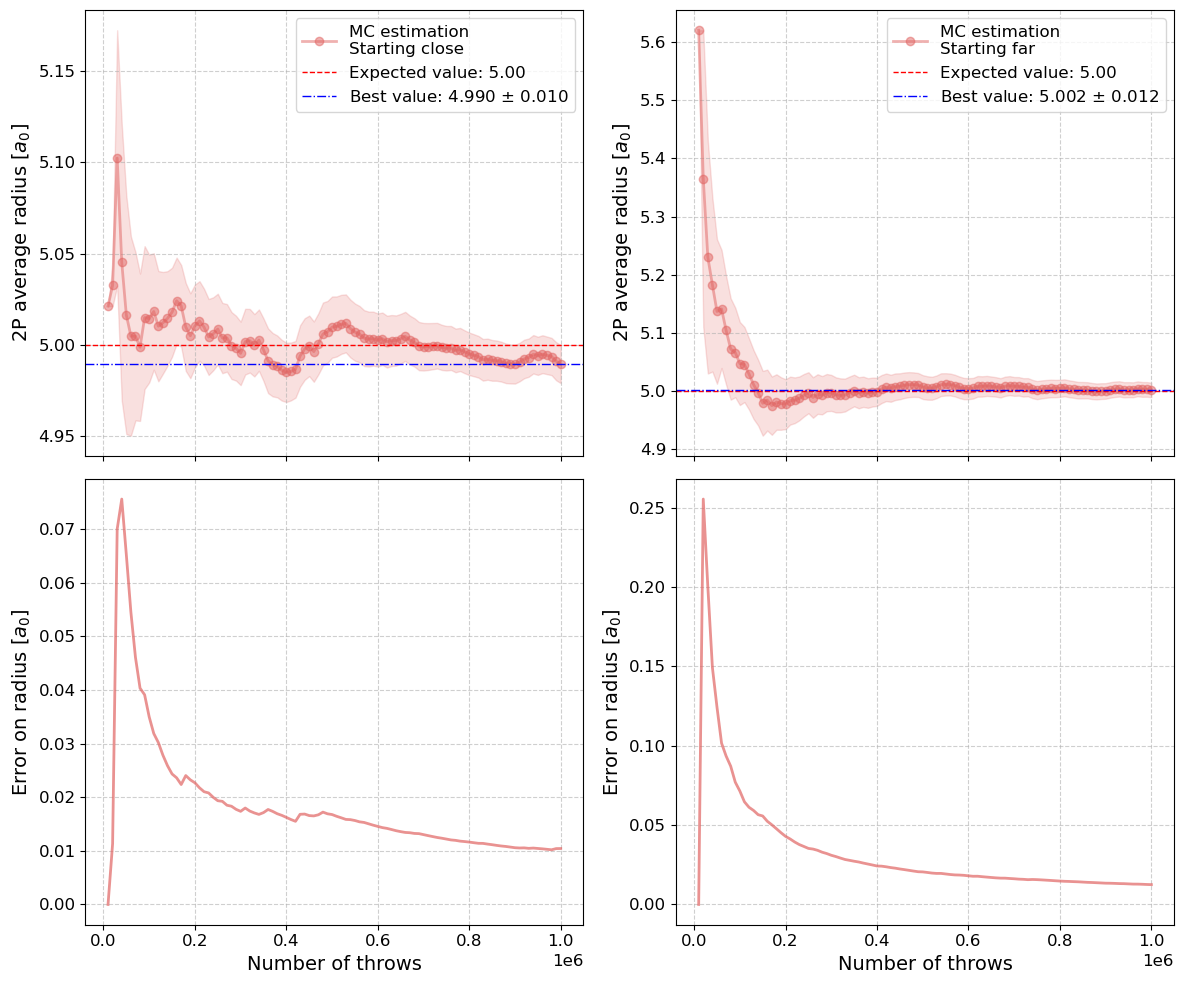

In [50]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

plasma = plt.cm.plasma
ref_color = 'red'
ref_color_2 = 'blue'
file_2p = "output_average_2p_gauss.data"
file_2p_far = "output_average_2p_far_gauss.data"
x_2p, y_2p, error_2p = np.loadtxt(file_2p, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x_2p_far, y_2p_far, error_2p_far = np.loadtxt(file_2p_far, usecols=(0, 1, 2), delimiter='\t', unpack=True)
color_2p = plasma(0.6)

# 2P - Near
ax[0, 0].plot(x_2p, y_2p, marker='o', color=color_2p, alpha=0.5, label='MC estimation \nStarting close')
ax[0, 0].fill_between(x_2p, y_2p+error_2p,y_2p-error_2p, color=color_2p, alpha=0.2)
ax[0, 0].axhline(y=5., color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 0].axhline(y=y_2p[99], color=ref_color_2, linestyle='-.', linewidth=1,
                     label=rf'Best value: {y_2p[99]:.3f} $\pm$ {error_2p[99]:.3f}')
ax[0, 0].set_ylabel('2P average radius [$a_0$]')
ax[0, 0].tick_params(axis='x', labelbottom=False)
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].legend()

# 2P - Far
ax[0, 1].plot(x_2p_far, y_2p_far, marker='o', color=color_2p, alpha=0.5, label='MC estimation \nStarting far')
ax[0, 1].fill_between(x_2p_far, y_2p_far+error_2p_far,y_2p_far-error_2p_far, color=color_2p, alpha=0.2)
ax[0, 1].axhline(y=5., color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 1].axhline(y=y_2p_far[99], color=ref_color_2, linestyle='-.', linewidth=1,
                     label=rf'Best value: {y_2p_far[99]:.3f} $\pm$ {error_2p_far[99]:.3f}')
ax[0, 1].tick_params(axis='x', labelbottom=False)
ax[0, 1].set_ylabel('2P average radius [$a_0$]')
ax[0, 1].grid(True, linestyle='--', alpha=0.6)
ax[0, 1].legend()

# Errori
ax[1, 0].plot(x_2p, error_2p, '-', color=color_2p, alpha=0.7)
ax[1, 0].set_xlabel('Number of throws')
ax[1, 0].set_ylabel('Error on radius [$a_0$]')
ax[1, 0].grid(True, linestyle='--', alpha=0.6)

ax[1, 1].plot(x_2p_far, error_2p_far, '-', color=color_2p, alpha=0.7)
ax[1, 1].set_xlabel('Number of throws')
ax[1, 1].set_ylabel('Error on radius [$a_0$]')
ax[1, 1].grid(True, linestyle='--', alpha=0.6)




plt.tight_layout()
plt.show()


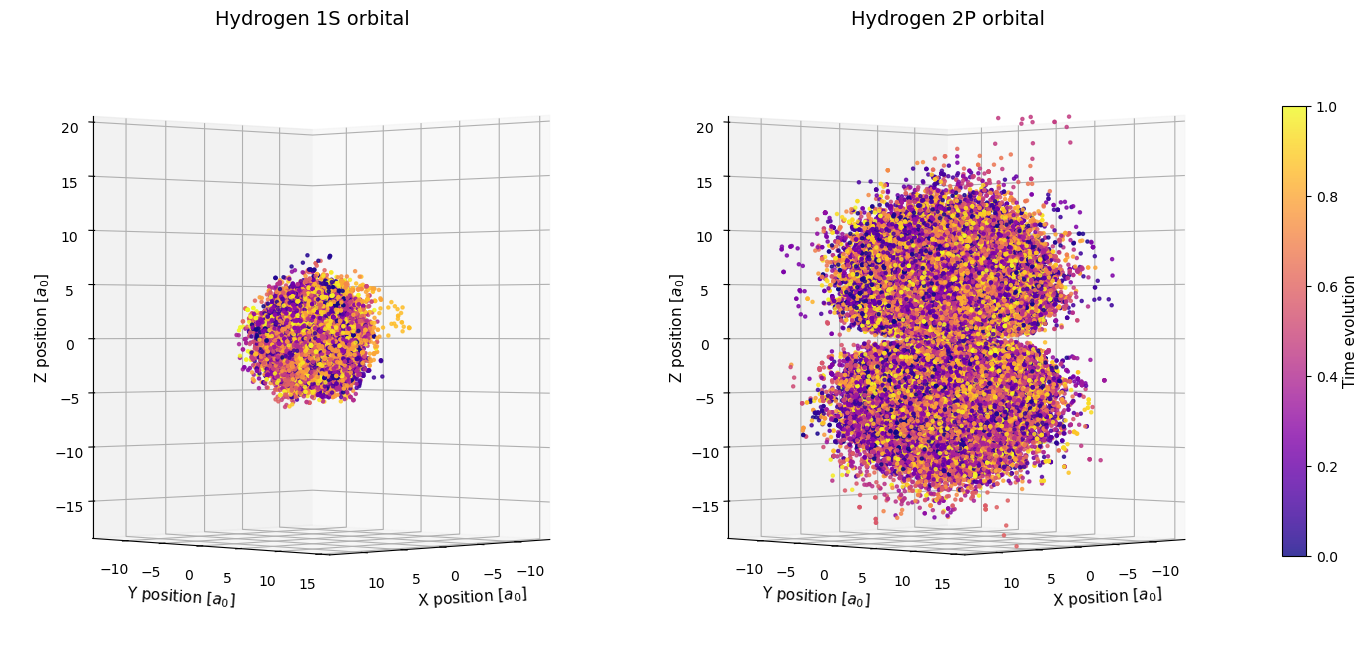

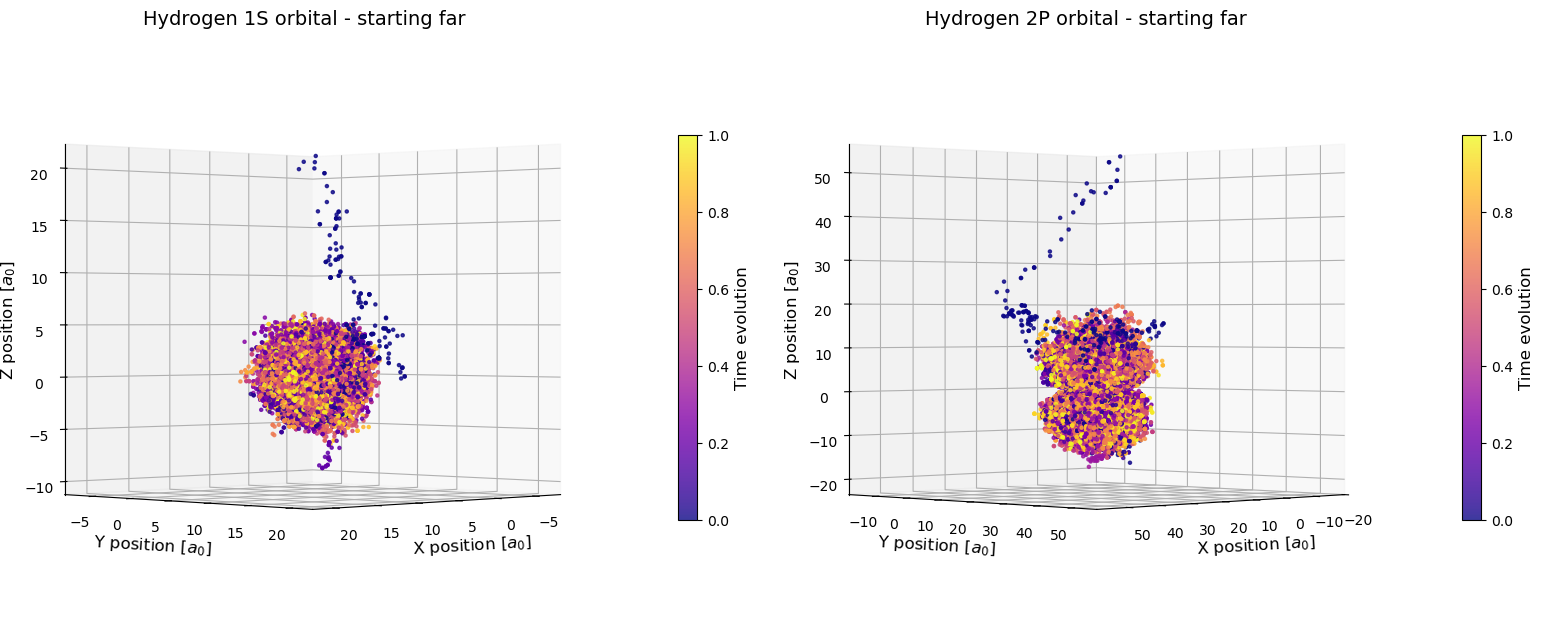

In [ ]:
data_1s = np.loadtxt("positions_1s_gauss.data")
data_2p = np.loadtxt("positions_2p_gauss.data")

all_data = np.vstack((data_1s, data_2p))
x_min, x_max = all_data[:, 0].min(), all_data[:, 0].max()
y_min, y_max = all_data[:, 1].min(), all_data[:, 1].max()
z_min, z_max = all_data[:, 2].min(), all_data[:, 2].max()

def set_equal_limits_and_aspect(ax):
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_box_aspect([x_max - x_min, y_max - y_min, z_max - z_min])

plt.style.use('default')
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

cmap = "plasma"
colors_1s = np.linspace(0, 1, len(data_1s))
colors_2p = np.linspace(0, 1, len(data_2p))

ax1 = fig.add_subplot(gs[0], projection='3d')
sc1 = ax1.scatter(data_1s[:, 0], data_1s[:, 1], data_1s[:, 2],
                  c=colors_1s, cmap=cmap, s=5, alpha=0.8)
ax1.set_title("Hydrogen 1S orbital", fontsize=14, color='black')
ax1.set_xlabel("X position [$a_0$]", fontsize=11)
ax1.set_ylabel("Y position [$a_0$]", fontsize=11)
ax1.set_zlabel("Z position [$a_0$]", fontsize=11)
ax1.view_init(elev=0, azim=45)
set_equal_limits_and_aspect(ax1)

ax2 = fig.add_subplot(gs[1], projection='3d')
sc2 = ax2.scatter(data_2p[:, 0], data_2p[:, 1], data_2p[:, 2],
                  c=colors_2p, cmap=cmap, s=5, alpha=0.8)
ax2.set_title("Hydrogen 2P orbital", fontsize=14, color='black')
ax2.set_xlabel("X position [$a_0$]", fontsize=11)
ax2.set_ylabel("Y position [$a_0$]", fontsize=11)
ax2.set_zlabel("Z position [$a_0$]", fontsize=11)
ax2.view_init(elev=0, azim=45)
set_equal_limits_and_aspect(ax2)

cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cbar = fig.colorbar(sc2, cax=cbar_ax)
cbar.set_label("Time evolution", fontsize=11)

plt.subplots_adjust(wspace=0.05, right=0.9)
plt.show()

# Starting far
#==============================================================================
data_1s_far = np.loadtxt("positions_1s_far_uniform.data")
data_2p_far = np.loadtxt("positions_2p_far_uniform.data")

fig2 = plt.figure(figsize=(16, 8))
ax3 = fig2.add_subplot(121, projection='3d')
colors_1s_far = np.linspace(0, 1, len(data_1s_far))
sc3 = ax3.scatter(data_1s_far[:, 0], data_1s_far[:, 1], data_1s_far[:, 2], 
                  c=colors_1s_far, cmap="plasma", s=5, alpha=0.8)

ax3.set_box_aspect((1, 1, 1)) 
cbar3 = fig2.colorbar(sc3, ax=ax3, shrink=0.5, pad=0.1)
cbar3.set_label("Time evolution", fontsize=12)

ax3.set_xlabel("X position [$a_0$]", fontsize=12)
ax3.set_ylabel("Y position [$a_0$]", fontsize=12)
ax3.set_zlabel("Z position [$a_0$]", fontsize=12)
ax3.set_title("Hydrogen 1S orbital - starting far", fontsize=14)
ax3.view_init(elev=0, azim=45)

ax4 = fig2.add_subplot(122, projection='3d')
colors_2p_far = np.linspace(0, 1, len(data_2p_far))
sc4 = ax4.scatter(data_2p_far[:, 0], data_2p_far[:, 1], data_2p_far[:, 2], 
                  c=colors_2p_far, cmap="plasma", s=5, alpha=0.8)
ax4.set_box_aspect((1, 1, 1))

cbar4 = fig2.colorbar(sc4, ax=ax4, shrink=0.5, pad=0.1)
cbar4.set_label("Time evolution", fontsize=12)

ax4.set_xlabel("X position [$a_0$]", fontsize=12)
ax4.set_ylabel("Y position [$a_0$]", fontsize=12)
ax4.set_zlabel("Z position [$a_0$]", fontsize=12)
ax4.set_title("Hydrogen 2P orbital - starting far ", fontsize=14)
ax4.view_init(elev=0, azim=45)

plt.tight_layout()
plt.show()
